# Section 4 Model Comparison

In [1]:
# Python version check
import sys
assert sys.version_info >= (3, 5), "Python 3.5 or later is required."

# Scikit-Learn version check
import sklearn
assert sklearn.__version__ >= "0.20", "Scikit-Learn 0.20 or later is required."

# Common imports
import os
import time
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Configure Matplotlib and Seaborn
plt.rc('axes', labelsize=14)
plt.rc('xtick', labelsize=12)
plt.rc('ytick', labelsize=12)
sns.set()

# Machine learning libraries
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, cross_validate
from sklearn.preprocessing import KBinsDiscretizer

# Utility libraries
import shutil
import joblib
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

In [2]:
# === Load measured data
measured_FSO = pd.read_csv('Data/Splitting/Validation/Generic/Y/y_val_FSO.csv').squeeze()
measured_RF = pd.read_csv('Data/Splitting/Validation/Generic/Y/y_val_RF.csv').squeeze()

# === Load predictions
m1_predicted_FSO = pd.read_csv('Data/Predicted/Validation/val_with_predicted_FSO.csv')['Predicted_FSO']
m1_predicted_RF = pd.read_csv('Data/Predicted/Validation/val_with_predicted_RF.csv')['Predicted_RF']

m2_predicted_FSO = pd.read_csv('Data/Predicted/Validation/val_with_predicted_m2.csv')['Predicted_FSO']
m2_predicted_RF = pd.read_csv('Data/Predicted/Validation/val_with_predicted_m2.csv')['Predicted_RF']

m3_predicted_FSO = pd.read_csv('Data/Predicted/Validation/val_with_predicted_m3.csv')['Predicted_FSO']
m3_predicted_RF = pd.read_csv('Data/Predicted/Validation/val_with_predicted_m3.csv')['Predicted_RF']

m4_predicted_FSO = pd.read_csv('Data/Predicted/Validation/val_ann_combined_prediction.csv')['Predicted_FSO']
m4_predicted_RF = pd.read_csv('Data/Predicted/Validation/val_ann_combined_prediction.csv')['Predicted_RF']

m5_predicted_FSO = pd.read_csv('Data/Predicted/Validation/val_cnn_combined_prediction.csv')['Predicted_FSO']
m5_predicted_RF = pd.read_csv('Data/Predicted/Validation/val_cnn_combined_prediction.csv')['Predicted_RF']


In [3]:
# --- Method Names 
methods = [
    'Method 1: Independent Random Forest',
    'Method 2: Joint Model (FSO → RF)',
    'Method 3: Joint Model (RF → FSO)',
    'Method 4: MLP',
    'Method 5: CNN'
]

In [4]:
fso_predictions = [m1_predicted_FSO, m2_predicted_FSO, m3_predicted_FSO, m4_predicted_FSO, m5_predicted_FSO]
rf_predictions = [m1_predicted_RF, m2_predicted_RF, m3_predicted_RF, m4_predicted_RF, m5_predicted_RF]

In [5]:
# --- SC Mapping
sc_mapping = {
    0: 'Clear Weather',
    3: 'Dust Storm',
    4: 'Fog',
    5: 'Drizzle',
    6: 'Rain',
    7: 'Snow',
    8: 'Showers'
}

sc_order = [0, 3, 4, 5, 6, 7, 8]  # Order
sc_names = [sc_mapping[sc] for sc in sc_order]
# Load corresponding SC labels (weather conditions)
sc_labels = pd.read_csv('Data/Predicted/Validation/val_with_predicted_m2.csv')['SC'].squeeze()

## Section 4.1 Model Accuracy

In [6]:
def compute_rmse_r2(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return rmse, r2

In [7]:
# === Calculate results for all methods
results = []

for method, fso_pred, rf_pred in zip(methods, fso_predictions, rf_predictions):
    fso_rmse, fso_r2 = compute_rmse_r2(measured_FSO, fso_pred)
    rf_rmse, rf_r2 = compute_rmse_r2(measured_RF, rf_pred)
    
    results.append({
        'Method': method,
        'FSO RMSE': fso_rmse,
        'RF RMSE': rf_rmse,
        'FSO R²': fso_r2,
        'RF R²': rf_r2
    })

# === Create and display results table
results_df = pd.DataFrame(results)

print(results_df)

                                Method  FSO RMSE   RF RMSE    FSO R²     RF R²
0  Method 1: Independent Random Forest  0.467687  0.336911  0.985166  0.990611
1     Method 2: Joint Model (FSO → RF)  0.467687  0.280277  0.985166  0.993502
2     Method 3: Joint Model (RF → FSO)  0.423277  0.336911  0.987849  0.990611
3                        Method 4: MLP  1.001943  0.625646  0.931917  0.967621
4                        Method 5: CNN  0.998587  0.668665  0.932373  0.963015


In [8]:
# --- Compute Metrics Per SC
sc_rmse_fso = {method: [] for method in methods}
sc_r2_fso = {method: [] for method in methods}
sc_rmse_rf = {method: [] for method in methods}
sc_r2_rf = {method: [] for method in methods}

for sc in sc_order:
    indices = sc_labels[sc_labels == sc].index
    y_true_fso = measured_FSO.loc[indices]
    y_true_rf = measured_RF.loc[indices]
    
    for method, fso_pred, rf_pred in zip(methods, fso_predictions, rf_predictions):
        pred_fso_sc = fso_pred.loc[indices]
        pred_rf_sc = rf_pred.loc[indices]
        
        fso_rmse, fso_r2 = compute_rmse_r2(y_true_fso, pred_fso_sc)
        rf_rmse, rf_r2 = compute_rmse_r2(y_true_rf, pred_rf_sc)
        
        sc_rmse_fso[method].append(fso_rmse)
        sc_r2_fso[method].append(fso_r2)
        sc_rmse_rf[method].append(rf_rmse)
        sc_r2_rf[method].append(rf_r2)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


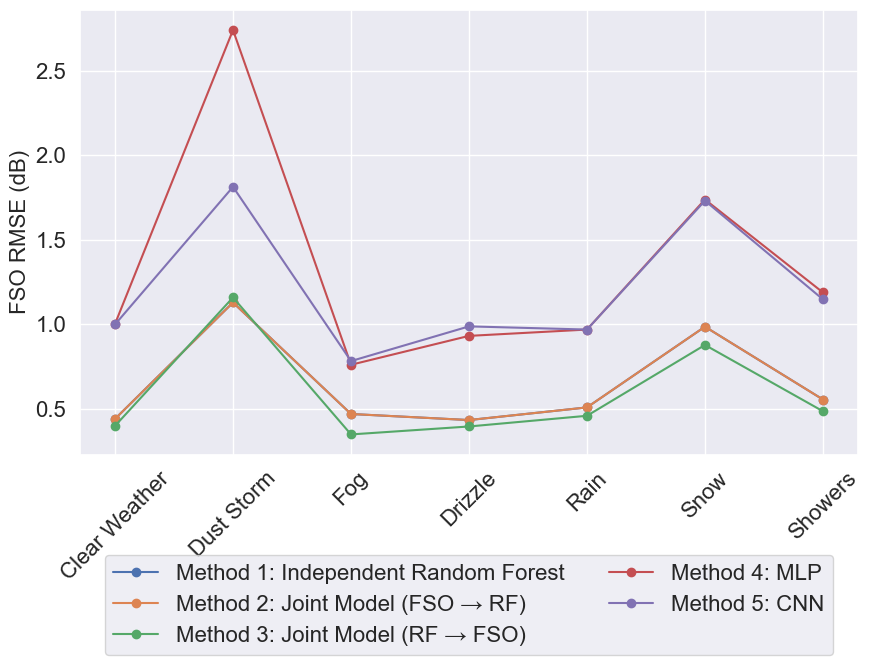

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


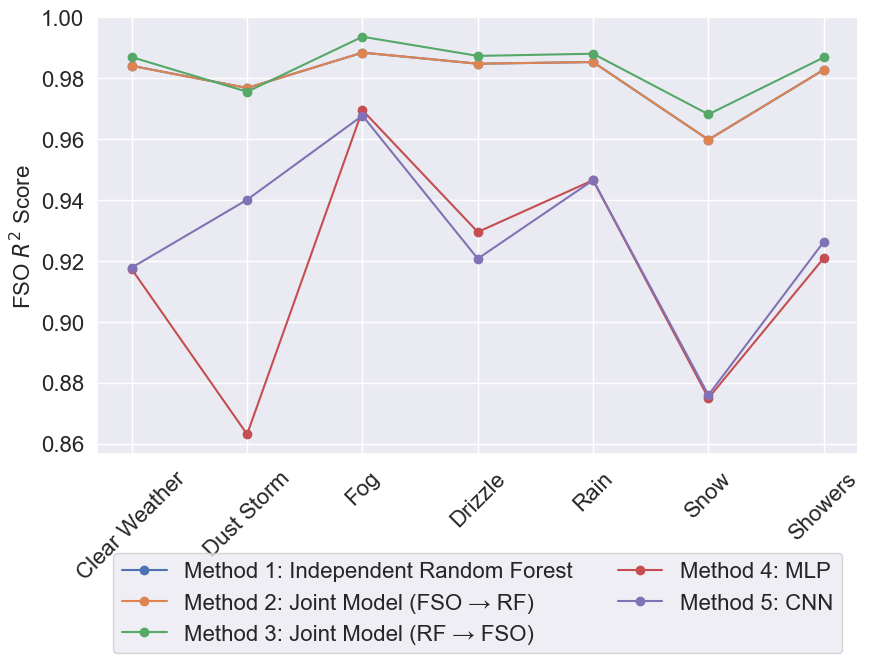

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


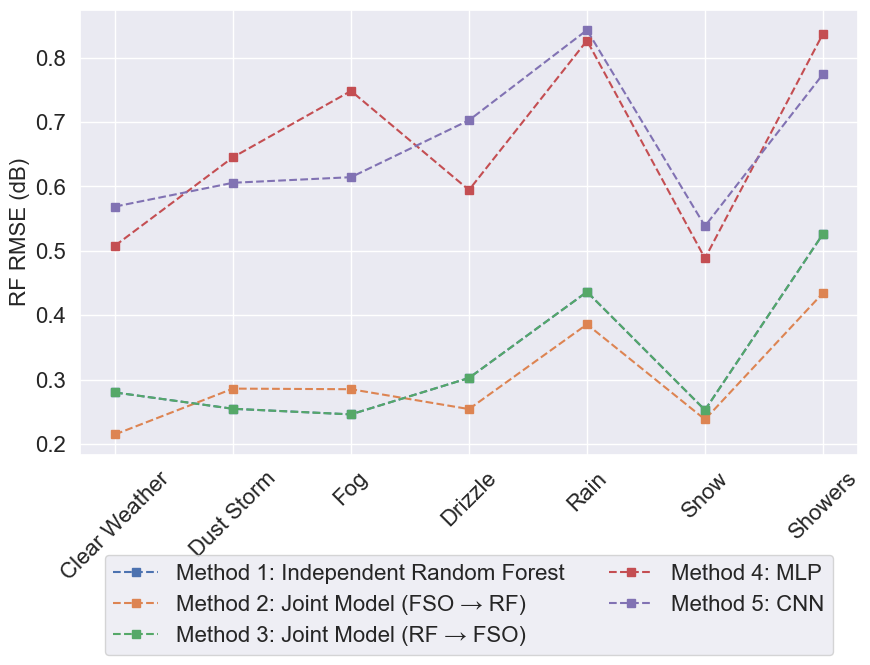

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


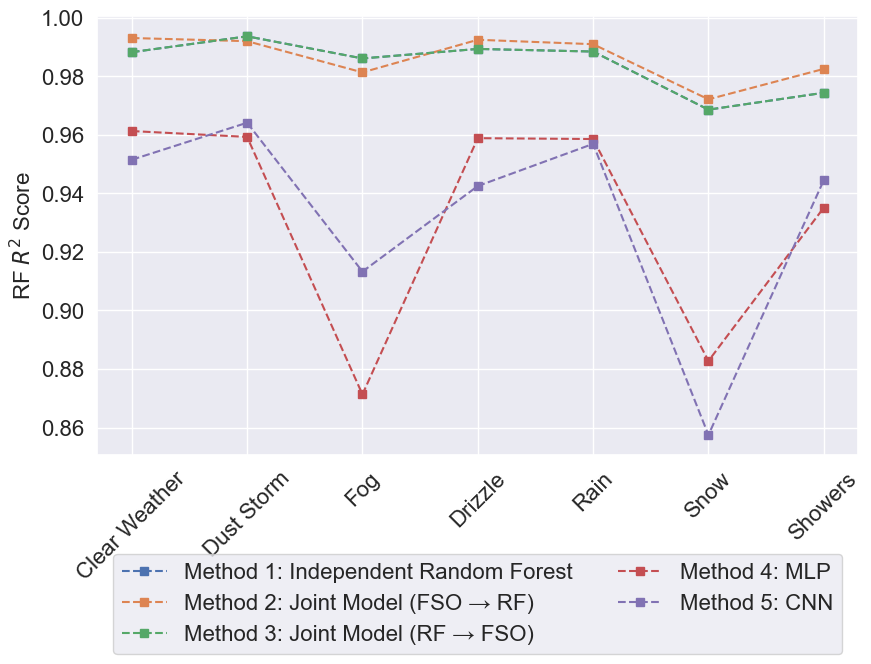

In [9]:
# Define the directory and filenames
output_dir = 'Figure/Comparison'

# === Plot FSO RMSE ===
plt.figure(figsize=(9, 7))
for method in methods:
    plt.plot(sc_names, sc_rmse_fso[method], marker='o', label=f'{method}')
#plt.title('FSO RMSE Across Weather Conditions', fontsize=20)
#plt.xlabel('Weather Condition', fontsize=16)
plt.ylabel('FSO RMSE (dB)', fontsize=16)
plt.grid(True)
plt.legend(fontsize=16,  loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2)
plt.xticks(rotation=45, fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()

# Create the directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)
eps_file = os.path.join(output_dir, 'FSO_RMSE.eps')
jpg_file = os.path.join(output_dir, 'FSO_RMSE.jpg')

# Save the plots
plt.savefig(eps_file, format='eps')
plt.savefig(jpg_file, format='jpg')

plt.show()

# === Plot FSO R² ===
plt.figure(figsize=(9, 7))
for method in methods:
    plt.plot(sc_names, sc_r2_fso[method], marker='o', label=f'{method}')
#plt.title('FSO $R^2$ Across Weather Conditions', fontsize=20)
#plt.xlabel('Weather Condition', fontsize=16)
plt.ylabel('FSO $R^2$ Score', fontsize=16)
plt.grid(True)
plt.legend(fontsize=16, loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2)
plt.xticks(rotation=45, fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()

# Create the directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)
eps_file = os.path.join(output_dir, 'FSO_R2.eps')
jpg_file = os.path.join(output_dir, 'FSO_R2.jpg')

# Save the plots
plt.savefig(eps_file, format='eps')
plt.savefig(jpg_file, format='jpg')

plt.show()

# === Plot RF RMSE ===
plt.figure(figsize=(9, 7))
for method in methods:
    plt.plot(sc_names, sc_rmse_rf[method], marker='s', linestyle='--', label=f'{method}')

##plt.xlabel('Weather Condition', fontsize=16)
plt.ylabel('RF RMSE (dB)', fontsize=16)
plt.grid(True)
plt.legend(fontsize=16,  loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2)  
plt.xticks(rotation=45, fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()

# Create the directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)
eps_file = os.path.join(output_dir, 'RF_RMSE.eps')
jpg_file = os.path.join(output_dir, 'RF_RMSE.jpg')

# Save the plots
plt.savefig(eps_file, format='eps')
plt.savefig(jpg_file, format='jpg')

plt.show()

# === Plot RF R² ===
plt.figure(figsize=(9, 7))
for method in methods:
    plt.plot(sc_names, sc_r2_rf[method], marker='s', linestyle='--', label=f'{method}')
#plt.xlabel('Weather Condition', fontsize=16)
plt.ylabel('RF $R^2$ Score', fontsize=16)
plt.grid(True)
plt.legend(fontsize=16,  loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2)
plt.xticks(rotation=45, fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()

# Create the directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)
eps_file = os.path.join(output_dir, 'RF_R2.eps')
jpg_file = os.path.join(output_dir, 'RF_R2.jpg')

# Save the plots
plt.savefig(eps_file, format='eps')
plt.savefig(jpg_file, format='jpg')

plt.show()

## Section 4.2 Model Correlation

### Section 4.2.1 Pearson Correlation

In [10]:
# --- Method Names 
methods = [
    'Measured Attenuation',
    'Method 1: Independent Random Forest',
    'Method 2: Joint Model (FSO → RF)',
    'Method 3: Joint Model (RF → FSO)'
]
fso_predictions = [measured_FSO, m1_predicted_FSO, m2_predicted_FSO, m3_predicted_FSO]
rf_predictions = [measured_RF, m1_predicted_RF, m2_predicted_RF, m3_predicted_RF]

In [11]:
# === Helper function to compute Pearson correlation
def compute_pearson_corr(y_true, y_pred):
    corr, _ = pearsonr(y_true, y_pred)
    return corr

# === Calculate results for all methods
correlation_results = []

for method, fso_pred, rf_pred in zip(methods, fso_predictions, rf_predictions):
    corr = compute_pearson_corr(fso_pred, rf_pred)
    
    correlation_results.append({
        'Method': method,
        'Pearson Correlation': corr
    })

# === Create and display correlation table
pcc_overall_df = pd.DataFrame(correlation_results)

print(pcc_overall_df)


                                Method  Pearson Correlation
0                 Measured Attenuation             0.078447
1  Method 1: Independent Random Forest             0.074573
2     Method 2: Joint Model (FSO → RF)             0.077599
3     Method 3: Joint Model (RF → FSO)             0.075542


In [12]:
def evaluate_pearson_correlation(
    rf_pred_path: str,
    fso_pred_path: str,
    method_name: str,
    correlation_df: pd.DataFrame = None,
    real_corr_dict: dict = None
):
    """
    Calculate Pearson correlation between RF and FSO predicted attenuation by SC
    and append the results as a new column to an existing DataFrame. Manually add
    the real Pearson correlation coefficient as the first column.

    Parameters:
    - rf_pred_path: Path to predicted RF validation dataset with 'Predicted_RF' column
    - fso_pred_path: Path to predicted FSO validation dataset with 'Predicted_FSO' column
    - method_name: Method label (e.g., "Method 1")
    - correlation_df: Existing DataFrame to append results to (default: None)
    - real_corr_dict: Dictionary of real Pearson correlations by SC (default: None)

    Returns:
    - correlation_df (DataFrame): Updated DataFrame with real correlations and a new column for the method's correlations
    """

    # Load predicted datasets
    val_rf = pd.read_csv(rf_pred_path)
    val_fso = pd.read_csv(fso_pred_path)

    # Combine predictions into a single DataFrame
    df = pd.DataFrame({
        'SC': val_rf['SC'],
        'Predicted_RF': val_rf['Predicted_RF'],
        'Predicted_FSO': val_fso['Predicted_FSO']
    })

    # Helper to calculate Pearson correlation
    def compute_corr(x, y):
        return pearsonr(x, y)[0]

    # Calculate SC-wise correlation
    results = []
    for sc in sorted(df['SC'].unique()):
        subset = df[df['SC'] == sc]
        pred_corr = compute_corr(subset['Predicted_RF'], subset['Predicted_FSO'])
        results.append({'SC': sc, method_name: pred_corr})

    # Convert results to a DataFrame
    method_corr_df = pd.DataFrame(results)

    # Add real correlations as the first column if provided
    if real_corr_dict is not None:
        method_corr_df['Real Correlation'] = method_corr_df['SC'].map(real_corr_dict)

    # Merge with the existing correlation DataFrame or initialize a new one
    if correlation_df is None:
        correlation_df = method_corr_df
    else:
        correlation_df = pd.merge(correlation_df, method_corr_df, on='SC', how='outer')

    # Ensure 'Real Correlation' is the first column
    if 'Real Correlation' in correlation_df.columns:
        cols = ['SC', 'Real Correlation'] + [col for col in correlation_df.columns if col not in ['SC', 'Real Correlation']]
        correlation_df = correlation_df[cols]

    return correlation_df

In [13]:
# Load the real RF and FSO attenuation data
y_rf_path = "Data/Splitting/Validation/Generic/Y/y_val_RF.csv"
y_fso_path = "Data/Splitting/Validation/Generic/Y/y_val_FSO.csv"
sc_path = "Data/Splitting/Validation/Generic/X/X_val.csv"  # Contains the SC column

# Load the data
y_rf = pd.read_csv(y_rf_path).squeeze()  # Real RF attenuation
y_fso = pd.read_csv(y_fso_path).squeeze()  # Real FSO attenuation
sc = pd.read_csv(sc_path)['SC']  # SC column

# Combine into a single DataFrame
df = pd.DataFrame({
    'SC': sc,
    'RFL_Att': y_rf,
    'FSO_Att': y_fso
})

# Calculate Pearson correlation by SC
real_corr_dict = {}
for sc_value in sorted(df['SC'].unique()):
    subset = df[df['SC'] == sc_value]
    corr, _ = pearsonr(subset['RFL_Att'], subset['FSO_Att'])
    real_corr_dict[sc_value] = round(corr, 4)

# Output the result
print("real_corr_dict =", real_corr_dict)

real_corr_dict = {0: -0.2846, 3: -0.3213, 4: 0.6413, 5: -0.1438, 6: 0.3301, 7: 0.7595, 8: -0.1135}


**(1) Method 1**

In [14]:
m1_rf_pred_path="Data/Predicted/Validation/val_with_predicted_RF.csv"
m1_fso_pred_path="Data/Predicted/Validation/val_with_predicted_FSO.csv"

In [15]:
# Initialize an empty DataFrame
correlation_df = None

# Call the function for Method 1
pcc_sc_df = evaluate_pearson_correlation(
    rf_pred_path=m1_rf_pred_path,
    fso_pred_path=m1_fso_pred_path,
    method_name="Method 1",
    correlation_df=correlation_df,
    real_corr_dict=real_corr_dict
)

pcc_sc_df

,SC,Real Correlation,Method 1
0,0,-0.2846,-0.303995
1,3,-0.3213,-0.403054
2,4,0.6413,0.672424
3,5,-0.1438,-0.155626
4,6,0.3301,0.330009
5,7,0.7595,0.723742
6,8,-0.1135,-0.144717


**(2) Method 2**

In [16]:
m2_rf_pred_path="Data/Predicted/Validation/val_with_predicted_m2.csv"
m2_fso_pred_path="Data/Predicted/Validation/val_with_predicted_m2.csv"

In [17]:
# Call the function for Method 2
pcc_sc_df = evaluate_pearson_correlation(
    rf_pred_path=m2_rf_pred_path,
    fso_pred_path=m2_fso_pred_path,
    method_name="Method 2",
    correlation_df=pcc_sc_df,
    real_corr_dict=None
)

pcc_sc_df

,SC,Real Correlation,Method 1,Method 2
0,0,-0.2846,-0.303995,-0.300634
1,3,-0.3213,-0.403054,-0.394415
2,4,0.6413,0.672424,0.654442
3,5,-0.1438,-0.155626,-0.154547
4,6,0.3301,0.330009,0.336103
5,7,0.7595,0.723742,0.739074
6,8,-0.1135,-0.144717,-0.125865


**(3) Method 3**

In [18]:
# Load the paths
m3_rf_pred_path="Data/Predicted/Validation/val_with_predicted_m3.csv"
m3_fso_pred_path="Data/Predicted/Validation/val_with_predicted_m3.csv"

In [19]:
# Call the function for Method 3
pcc_sc_df = evaluate_pearson_correlation(
    rf_pred_path=m3_rf_pred_path,
    fso_pred_path=m3_fso_pred_path,
    method_name="Method 3",
    correlation_df=pcc_sc_df,
    real_corr_dict=None
)

pcc_sc_df

,SC,Real Correlation,Method 1,Method 2,Method 3
0,0,-0.2846,-0.303995,-0.300634,-0.304404
1,3,-0.3213,-0.403054,-0.394415,-0.392743
2,4,0.6413,0.672424,0.654442,0.671075
3,5,-0.1438,-0.155626,-0.154547,-0.155986
4,6,0.3301,0.330009,0.336103,0.333927
5,7,0.7595,0.723742,0.739074,0.732306
6,8,-0.1135,-0.144717,-0.125865,-0.146381


## Section 4.2 Mutual Information

In [20]:
def compute_entropy(probs):
    """Compute entropy H(X) = -∑ p(x) log(p(x))"""
    probs = probs[probs > 0]
    return -np.sum(probs * np.log(probs))

In [21]:
def calculate_NMI(x, y, bin_width = 0.5):
    
    bins_x = np.arange(np.min(x), np.max(x) + bin_width, bin_width)
    bins_y = np.arange(np.min(y), np.max(y) + bin_width, bin_width)

    # 1. Discretize the data into bins
    counts_x, _ = np.histogram(x, bins=bins_x, density=False)
    counts_y, _ = np.histogram(y, bins=bins_y, density=False)
    counts_xy, _, _ = np.histogram2d(x, y, bins=[bins_x, bins_y], density=False)

    # 2. Normalize to get probabilities
    p_x = counts_x / np.sum(counts_x)
    p_y = counts_y / np.sum(counts_y)
    p_xy = counts_xy / np.sum(counts_xy)

    # 3. Calculate entropies
    H_X = compute_entropy(p_x)
    H_Y = compute_entropy(p_y)
    H_XY = compute_entropy(p_xy.flatten())  # Flatten joint distribution

    # 4. Mutual information
    mutual_info = H_X + H_Y - H_XY
    NMI = mutual_info / H_XY

    return NMI


In [22]:
# === Calculate results for all methods
NMI_results = []

for method, fso_pred, rf_pred in zip(methods, fso_predictions, rf_predictions):
    nmi = calculate_NMI(fso_pred, rf_pred, 0.5)
    
    NMI_results.append({
        'Method': method,
        'NMI': nmi
    })

# === Create and display correlation table
nmi_overall_df = pd.DataFrame(NMI_results)

print(nmi_overall_df)

                                Method       NMI
0                 Measured Attenuation  0.059365
1  Method 1: Independent Random Forest  0.066361
2     Method 2: Joint Model (FSO → RF)  0.063556
3     Method 3: Joint Model (RF → FSO)  0.066413


In [23]:
def evaluate_mutual_information(
    rf_pred_path: str,
    fso_pred_path: str,
    method_name: str,
    nmi_df: pd.DataFrame = None,
    real_nmi_dict: dict = None,
    bin_width: float = 0.5
):
    """
    Evaluate mutual information (NMI) between RF and FSO predicted attenuation by SC
    and append the results as a new column to an existing DataFrame. Manually add
    the real NMI as the first column.

    Parameters:
    - rf_pred_path: Path to predicted RF validation dataset with 'Predicted_RF' column
    - fso_pred_path: Path to predicted FSO validation dataset with 'Predicted_FSO' column
    - method_name: Method label (e.g., "Method 1")
    - nmi_df: Existing DataFrame to append results to (default: None)
    - real_nmi_dict: Dictionary of real NMI values by SC (default: None)
    - bin_width: Bin width for calculating NMI (default: 0.1)

    Returns:
    - nmi_df (DataFrame): Updated DataFrame with real NMI and a new column for the method's NMI
    """

    # Load predicted datasets
    val_rf = pd.read_csv(rf_pred_path)
    val_fso = pd.read_csv(fso_pred_path)

    # Combine predictions into a single DataFrame
    df = pd.DataFrame({
        'SC': val_rf['SC'],
        'Predicted_RF': val_rf['Predicted_RF'],
        'Predicted_FSO': val_fso['Predicted_FSO']
    })


    # Calculate SC-wise NMI
    results = []
    for sc in sorted(df['SC'].unique()):
        subset = df[df['SC'] == sc]
        pred_nmi = calculate_NMI(subset['Predicted_RF'], subset['Predicted_FSO'], bin_width=bin_width)
        results.append({'SC': sc, method_name: pred_nmi})

    # Convert results to a DataFrame
    method_nmi_df = pd.DataFrame(results)

    # Add real NMI as the first column if provided
    if real_nmi_dict is not None:
        method_nmi_df['Real NMI'] = method_nmi_df['SC'].map(real_nmi_dict)

    # Merge with the existing NMI DataFrame or initialize a new one
    if nmi_df is None:
        nmi_df = method_nmi_df
    else:
        nmi_df = pd.merge(nmi_df, method_nmi_df, on='SC', how='outer')

    # Ensure 'Real NMI' is the first column
    if 'Real NMI' in nmi_df.columns:
        cols = ['SC', 'Real NMI'] + [col for col in nmi_df.columns if col not in ['SC', 'Real NMI']]
        nmi_df = nmi_df[cols]

    return nmi_df

In [24]:
def plot_joint_histograms(
    rf_pred_path: str,
    fso_pred_path: str,
    method_name: str,
    bin_width: float = 0.5
):
    """
    Plot joint histograms of RF vs. FSO predicted attenuation,
    overall and by SC subset, in a grid layout with 3 columns.

    Parameters:
    - rf_pred_path: CSV path with RF predictions
    - fso_pred_path: CSV path with FSO predictions
    - method_name: method name used in plot titles
    - bin_width: bin width for both axes
    """

    # Load data
    val_rf = pd.read_csv(rf_pred_path)
    val_fso = pd.read_csv(fso_pred_path)

    # Combine data into a single DataFrame
    df = pd.DataFrame({
        'SC': val_rf['SC'],
        'Predicted_RF': val_rf['Predicted_RF'],
        'Predicted_FSO': val_fso['Predicted_FSO']
    })

    def plot_heatmap(ax, x, y, title):
        """
        Helper function to plot a 2D histogram (heatmap) on a given axis.
        """
        bins = np.arange(np.min(x), np.max(x) + bin_width, bin_width)
        h = ax.hist2d(x, y, bins=bins, cmap='viridis', cmin=1)
        plt.colorbar(h[3], ax=ax, label='Count', shrink=0.85)
        ax.set_xlabel("Predicted RF Att. (dB)", fontsize=10)
        ax.set_ylabel("Predicted FSO Att. (dB)", fontsize=10)
        ax.set_title(title, fontsize=12)
        ax.grid(visible=True, which='both', color='gray', linestyle='--', linewidth=0.3)

    # === Overall plot ===
    num_sc = len(df["SC"].unique())
    total_plots = num_sc + 1  # Include the overall plot
    rows = (total_plots + 2) // 3  # Calculate the number of rows for 3 columns

    fig, axes = plt.subplots(rows, 3, figsize=(15, 5 * rows))
    axes = axes.flatten()  # Flatten the axes array for easy indexing

    # Plot the overall heatmap
    plot_heatmap(
        axes[0], df["Predicted_RF"], df["Predicted_FSO"],
        f"Overall - Predicted Attenuation ({method_name})"
    )

    # Plot SC-wise heatmaps
    for i, sc in enumerate(sorted(df["SC"].unique()), start=1):
        df_sc = df[df["SC"] == sc]
        plot_heatmap(
            axes[i], df_sc["Predicted_RF"], df_sc["Predicted_FSO"],
            f"SC {sc} - Predicted Attenuation ({method_name})"
        )

    # Hide any unused subplots
    for j in range(total_plots, len(axes)):
        fig.delaxes(axes[j])

    # Adjust layout and display the figure
    plt.tight_layout()
    plt.show()

In [25]:
# Load the real RF and FSO attenuation data
y_rf_path = "Data/Splitting/Validation/Generic/Y/y_val_RF.csv"
y_fso_path = "Data/Splitting/Validation/Generic/Y/y_val_FSO.csv"
sc_path = "Data/Splitting/Validation/Generic/X/X_val.csv"  # Contains the SC column

# Load the data
y_rf = pd.read_csv(y_rf_path).squeeze()  # Real RF attenuation
y_fso = pd.read_csv(y_fso_path).squeeze()  # Real FSO attenuation
sc = pd.read_csv(sc_path)['SC']  # SC column

# Combine into a single DataFrame
df = pd.DataFrame({
    'SC': sc,
    'RFL_Att': y_rf,
    'FSO_Att': y_fso
})

# Calculate Pearson correlation by SC
real_nmi_dict = {}
for sc_value in sorted(df['SC'].unique()):
    subset = df[df['SC'] == sc_value]
    pred_nmi = calculate_NMI(subset['RFL_Att'], subset['FSO_Att'], bin_width=0.5)
    real_nmi_dict[sc_value] = round(pred_nmi, 4)

# Output the result
print("real_nmi_dict =", real_nmi_dict)

real_nmi_dict = {0: 0.0642, 3: 0.5494, 4: 0.4241, 5: 0.1148, 6: 0.0857, 7: 0.3115, 8: 0.2346}


**(1) Method 1**

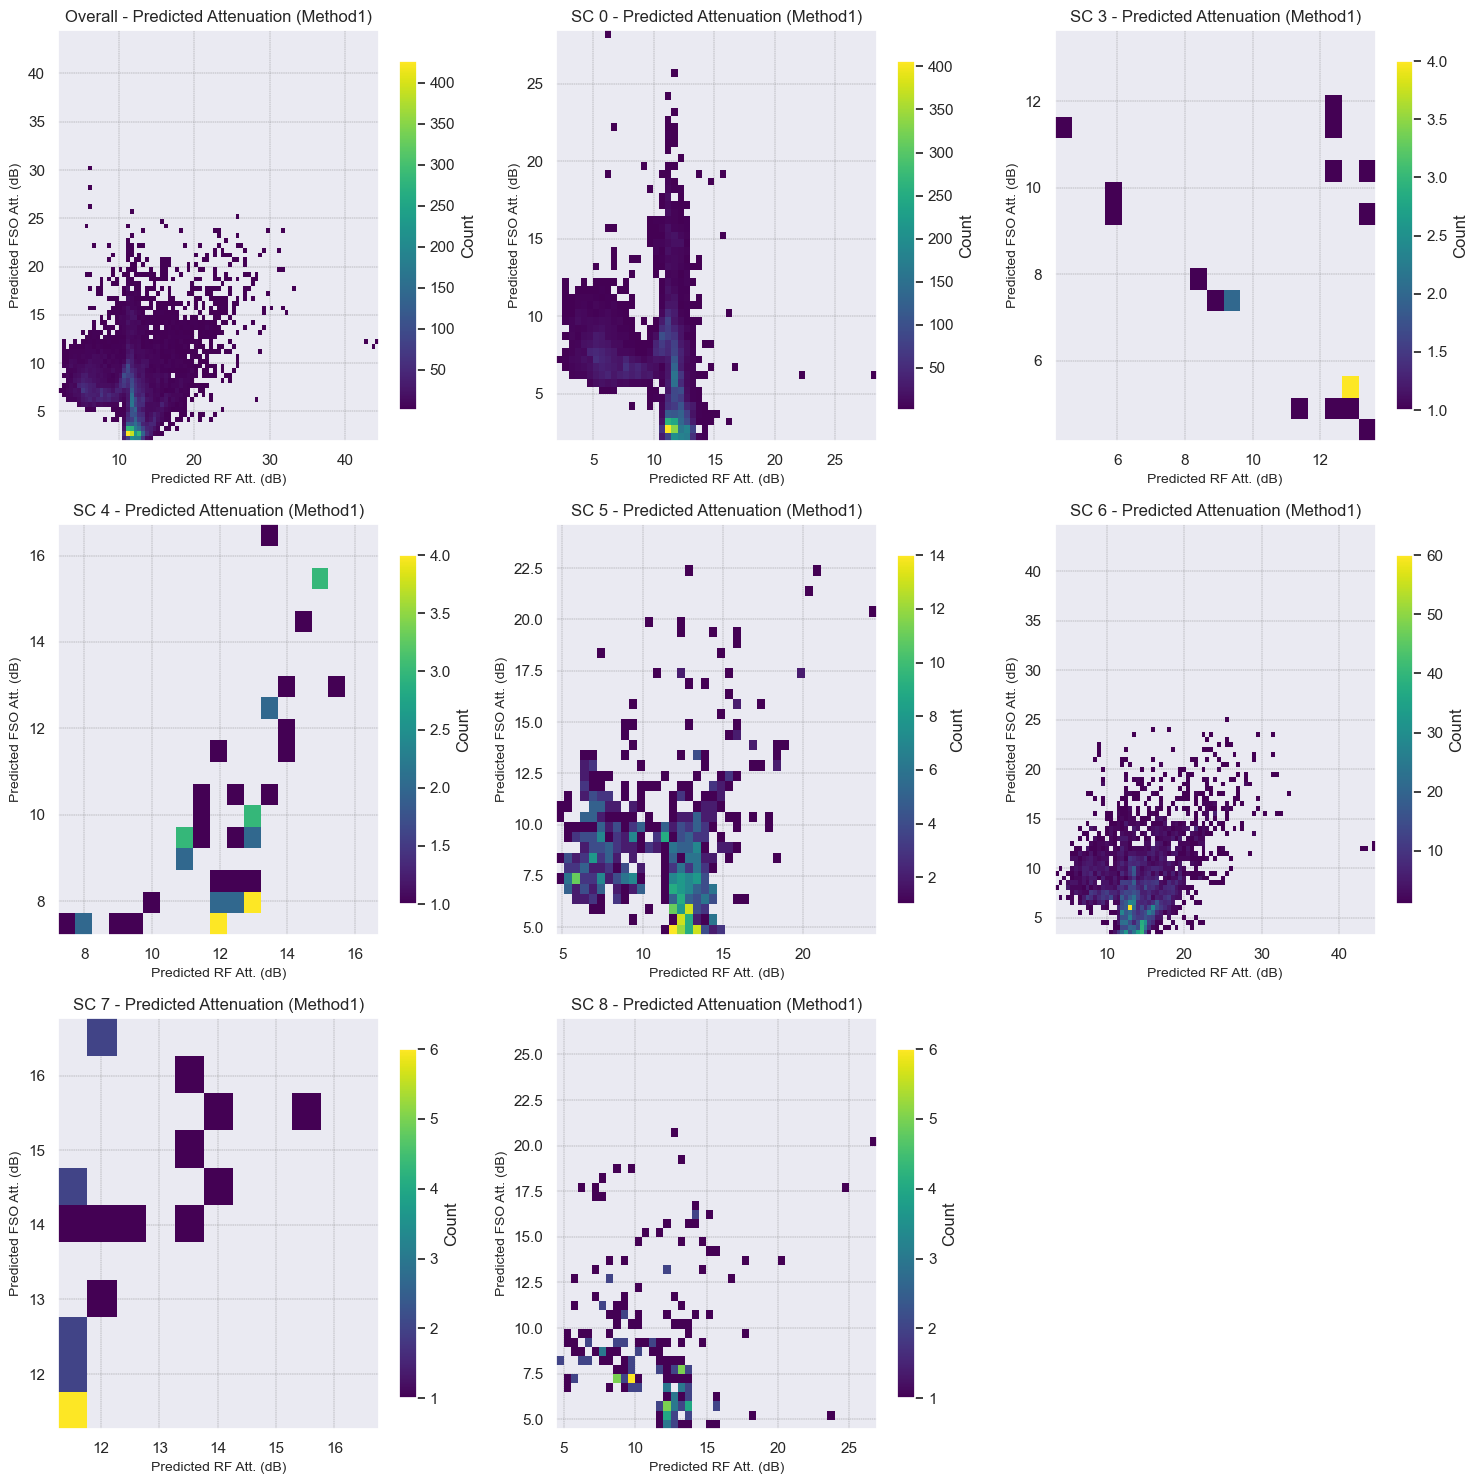

In [26]:
plot_joint_histograms(
    rf_pred_path=m1_rf_pred_path,
    fso_pred_path=m1_fso_pred_path,
    method_name="Method1",
    bin_width=0.5,
)


In [27]:
# Initialize an empty DataFrame
nmi_sc_df = None

# Call the function for Method 1
nmi_sc_df = evaluate_mutual_information(
    rf_pred_path= m1_rf_pred_path,
    fso_pred_path=m1_fso_pred_path,
    method_name="Method 1",
    nmi_df=nmi_sc_df,
    real_nmi_dict=real_nmi_dict,
    bin_width=0.5
)

In [28]:
nmi_sc_df

,SC,Real NMI,Method 1
0,0,0.0642,0.077137
1,3,0.5494,0.586418
2,4,0.4241,0.470798
3,5,0.1148,0.119555
4,6,0.0857,0.088435
5,7,0.3115,0.320990
6,8,0.2346,0.247507


**(2) Method 2**

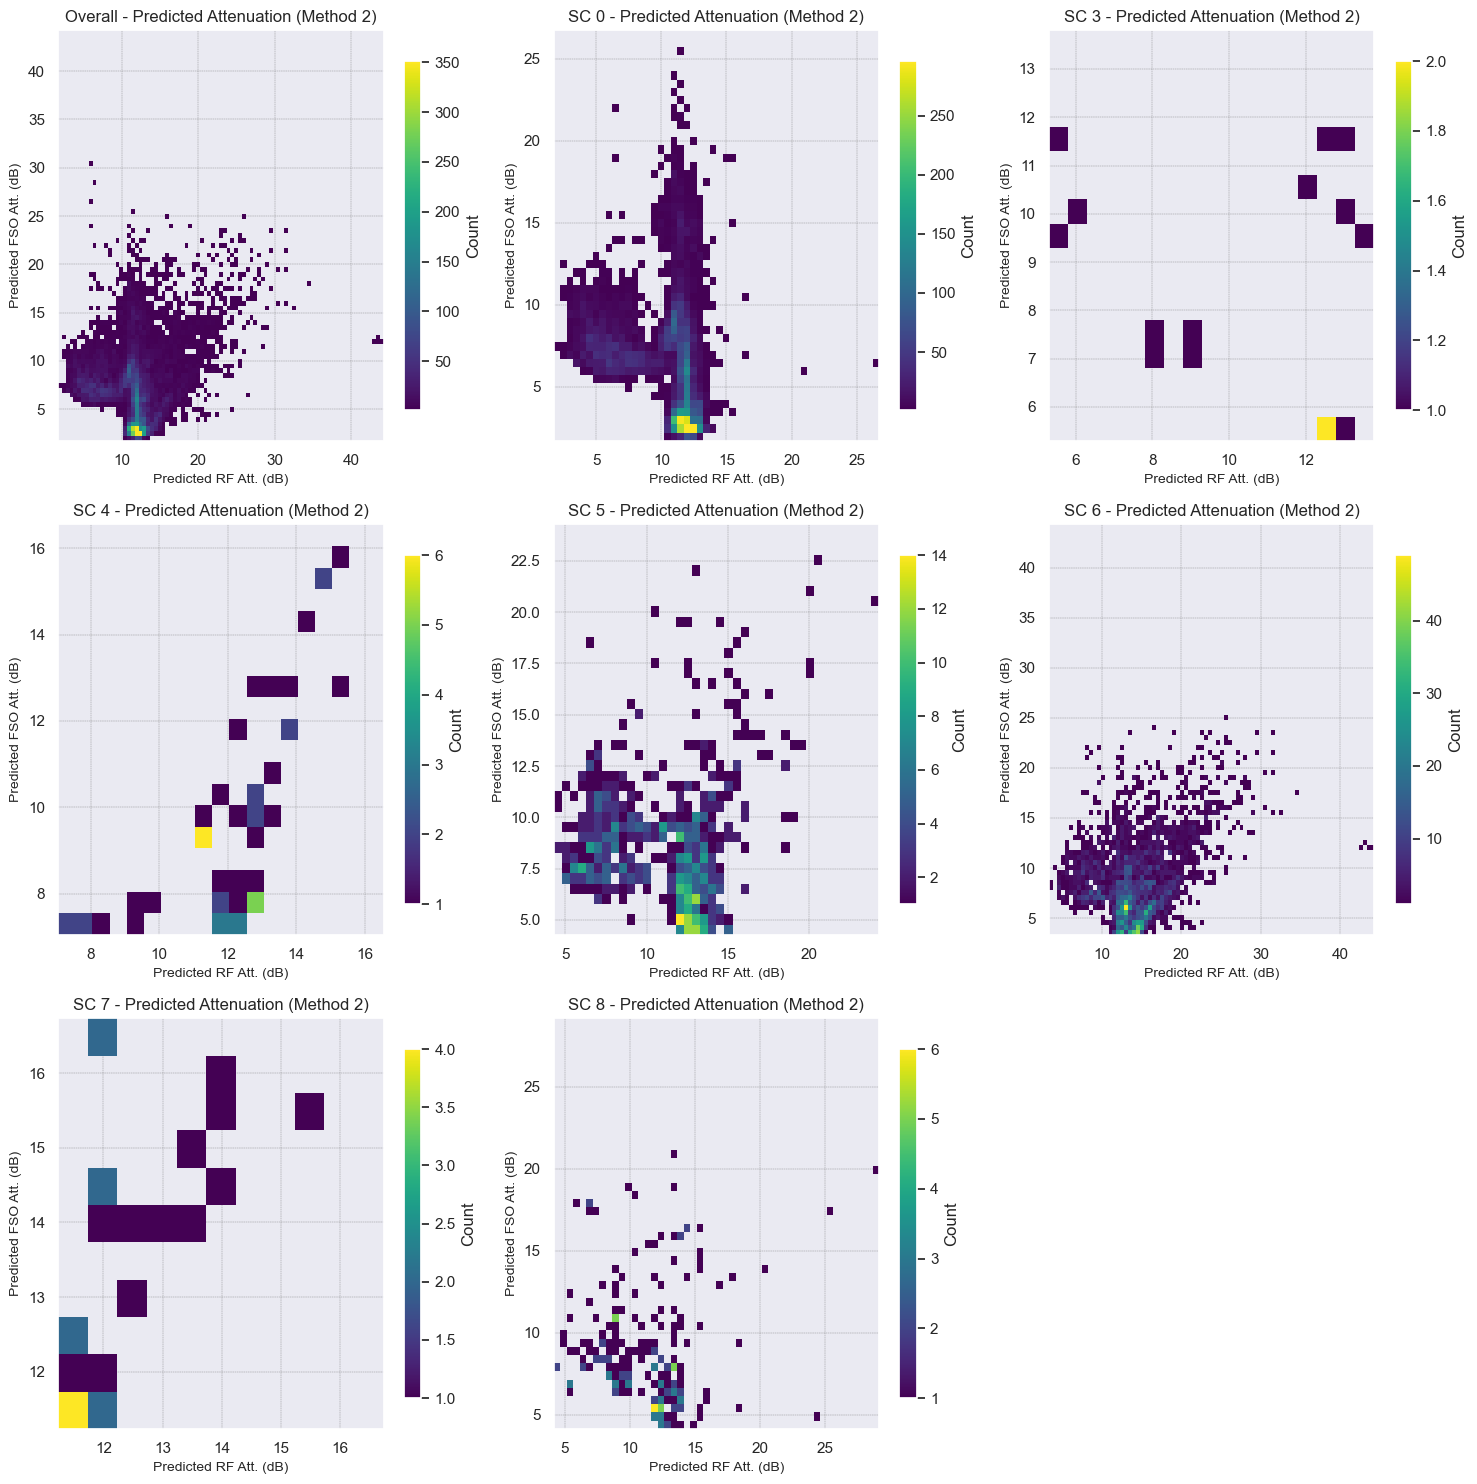

In [29]:

plot_joint_histograms(
    rf_pred_path=m2_rf_pred_path,
    fso_pred_path=m2_fso_pred_path,
    method_name="Method 2",
    bin_width=0.5,
)


In [30]:
# Call the function for Method 2
nmi_sc_df = evaluate_mutual_information(
    rf_pred_path= m2_rf_pred_path,
    fso_pred_path=m2_fso_pred_path,
    method_name="Method 2",
    nmi_df=nmi_sc_df,
    real_nmi_dict=None,
    bin_width=0.5
)

In [31]:
nmi_sc_df

,SC,Real NMI,Method 1,Method 2
0,0,0.0642,0.077137,0.070965
1,3,0.5494,0.586418,0.533745
2,4,0.4241,0.470798,0.415779
3,5,0.1148,0.119555,0.117513
4,6,0.0857,0.088435,0.087660
5,7,0.3115,0.320990,0.348454
6,8,0.2346,0.247507,0.241824


**(3) Method 3**

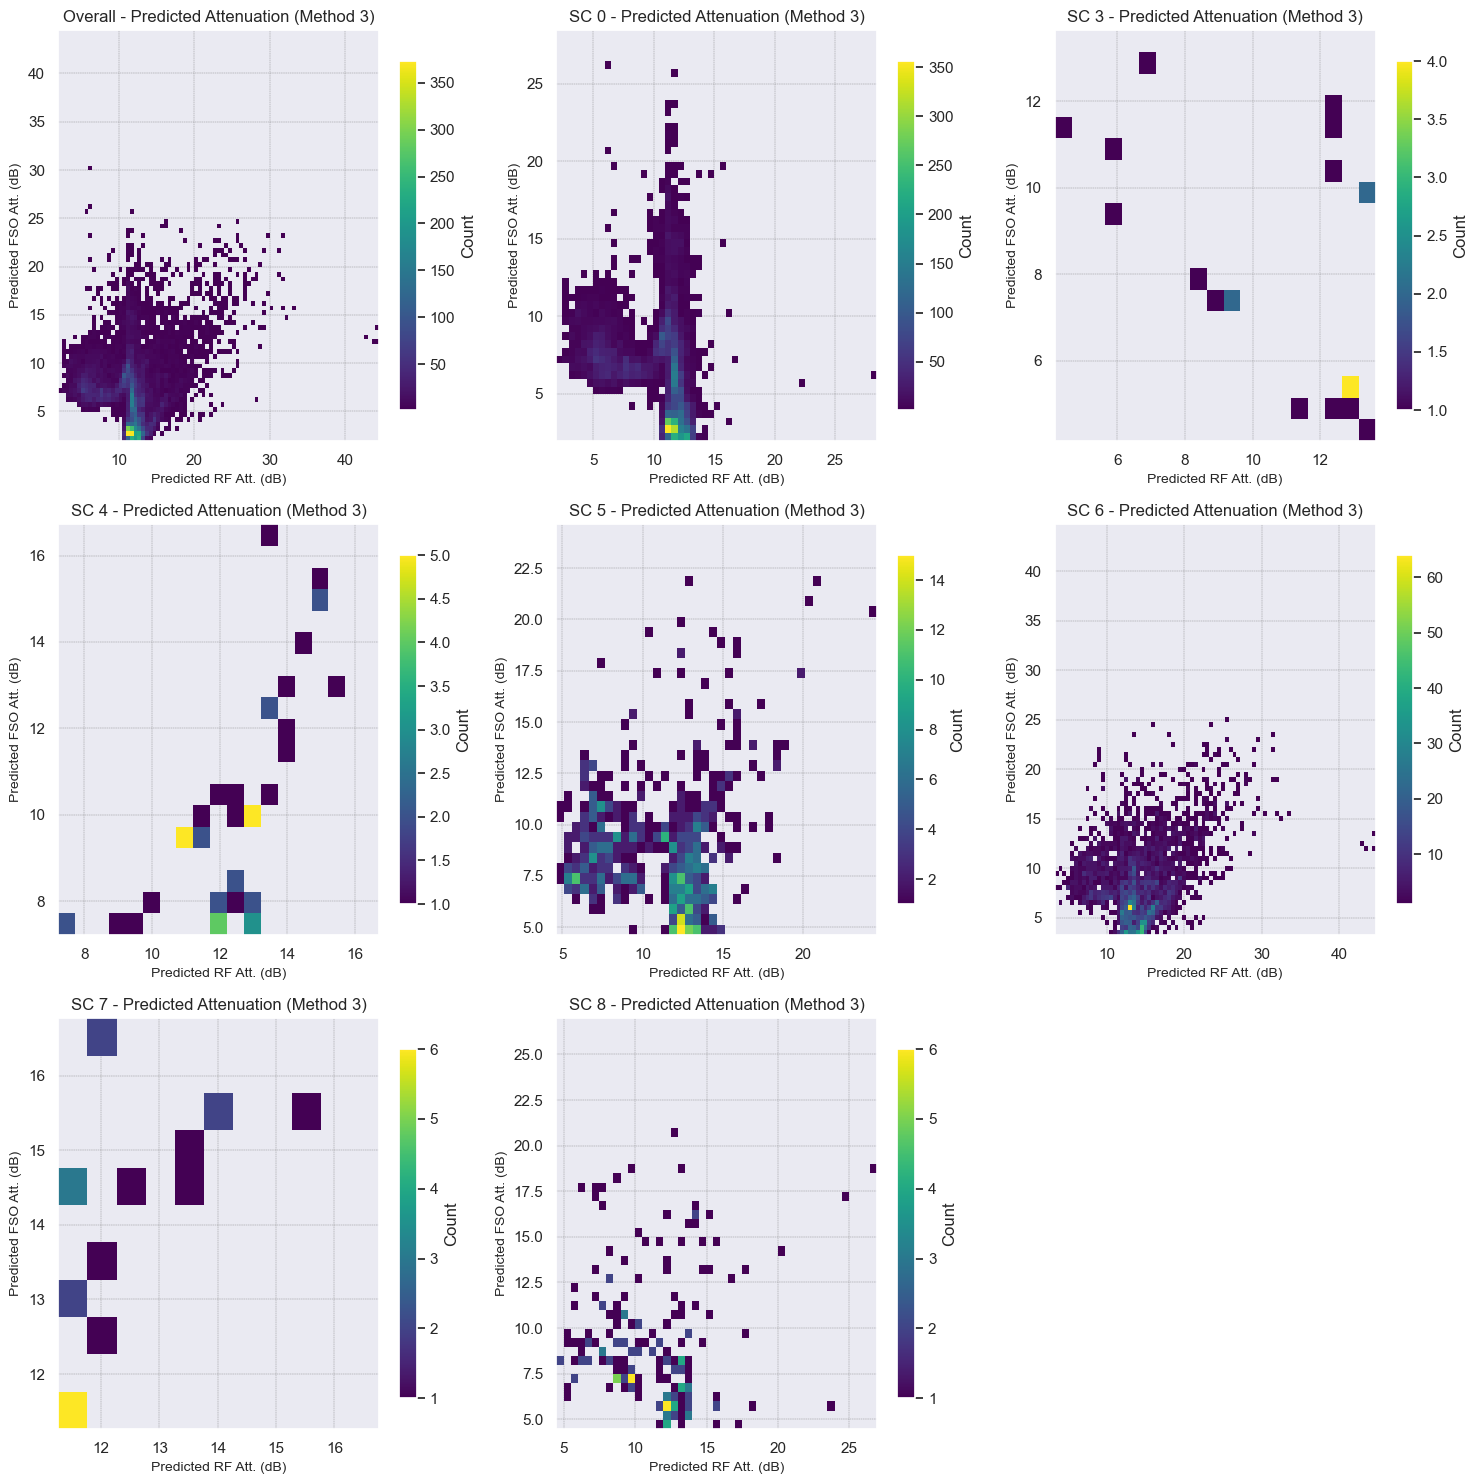

In [32]:

plot_joint_histograms(
    rf_pred_path=m3_rf_pred_path,
    fso_pred_path=m3_fso_pred_path,
    method_name="Method 3",
    bin_width=0.5,
)

In [33]:
# Call the function for Method 3
nmi_sc_df = evaluate_mutual_information(
    rf_pred_path= m3_rf_pred_path,
    fso_pred_path=m3_fso_pred_path,
    method_name="Method 3",
    nmi_df=nmi_sc_df,
    real_nmi_dict=None,
    bin_width=0.5
)

In [34]:
nmi_sc_df

,SC,Real NMI,Method 1,Method 2,Method 3
0,0,0.0642,0.077137,0.070965,0.076426
1,3,0.5494,0.586418,0.533745,0.600815
2,4,0.4241,0.470798,0.415779,0.481136
3,5,0.1148,0.119555,0.117513,0.116260
4,6,0.0857,0.088435,0.087660,0.088791
5,7,0.3115,0.320990,0.348454,0.320454
6,8,0.2346,0.247507,0.241824,0.237633


## Section 4.3 Plot Correlation

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


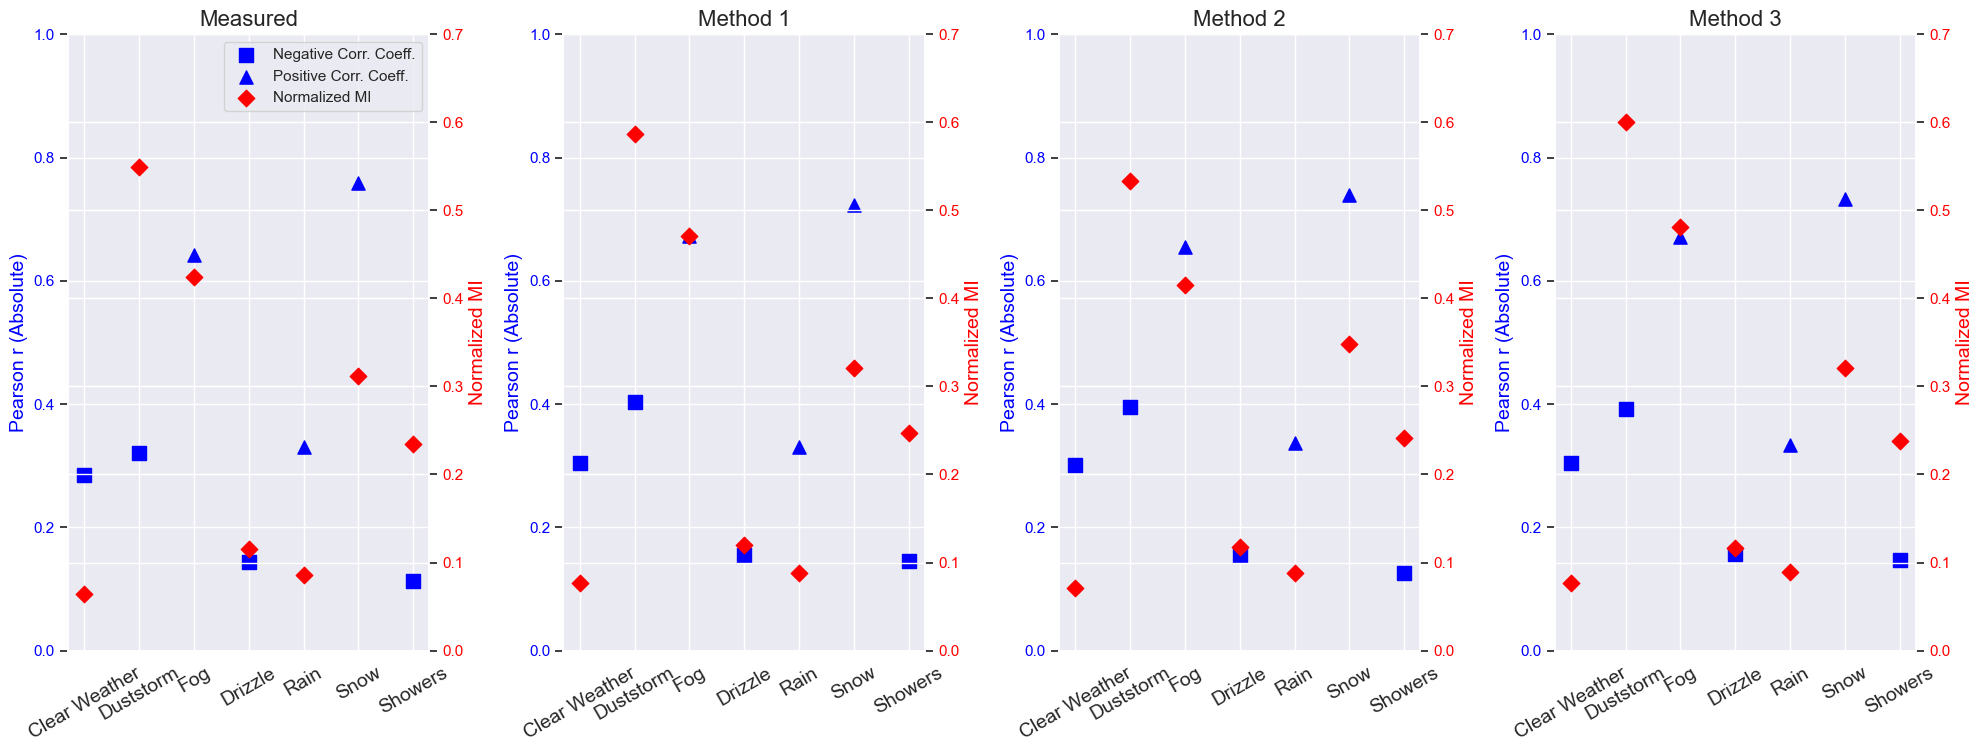

In [35]:
# Weather condition labels
sc_labels = ['Clear Weather', 'Duststorm', 'Fog', 'Drizzle', 'Rain', 'Snow', 'Showers']

# Correlation data per method from your DataFrames
correlation_data = {}
methods = ['Real', 'Method 1', 'Method 2', 'Method 3']

for method in methods:
    # Adjust key for 'Measured' instead of 'Real'
    key = 'Measured' if method == 'Real' else method

    correlation_data[key] = {
        'PCC': pcc_sc_df['Real Correlation'].abs() if method == 'Real' else pcc_sc_df[method].abs(),
        'NMI': nmi_sc_df['Real NMI'] if method == 'Real' else nmi_sc_df[method]
    }

# Plotting
fig, axes = plt.subplots(1, 4, figsize=(20, 8))
axes = axes.flatten()

for i, (method, values) in enumerate(correlation_data.items()):
    ax1 = axes[i]
    pcc = values['PCC']
    nmi = values['NMI']
    
        
    for j, r in enumerate(pcc):
        original_pcc = pcc_sc_df['Real Correlation'][j] if method == 'Measured' else pcc_sc_df[method][j]
        marker = '^' if original_pcc >= 0 else 's'
        ax1.scatter(j, r, color='blue', marker=marker, s=90)

    # Force legend handles to always show both markers
    ax1.scatter([], [], color='blue', marker='s', s=90, label='Negative Corr. Coeff.')
    ax1.scatter([], [], color='blue', marker='^', s=90, label='Positive Corr. Coeff.')
    
    ax1.set_ylabel('Pearson r (Absolute)', color='blue', fontsize=14)
    ax1.set_ylim(0, 1.0)  # Start from 0
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.set_xticks(range(len(sc_labels)))
    ax1.set_xticklabels(sc_labels, rotation=30, fontsize=14)

    # Secondary axis for NMI
    ax2 = ax1.twinx()
    ax2.scatter(range(len(sc_labels)), nmi, color='red', marker='D', s=70, label='Normalized MI' if i == 0 else "")
    ax2.set_ylabel('Normalized MI', color='red', fontsize=14)
    ax2.set_ylim(0, 0.7)
    ax2.tick_params(axis='y', labelcolor='red')
    
    ax1.set_title(method, fontsize=16)

    if i == 0:
        h1, l1 = ax1.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax1.legend(h1 + h2, l1 + l2, loc='upper right')

plt.tight_layout(rect=[0, 0, 1, 0.96])

# Create the directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)
eps_file = os.path.join(output_dir, 'correlation.eps')
jpg_file = os.path.join(output_dir, 'correlation.jpg')

# Save the plots
plt.savefig(eps_file, format='eps')
plt.savefig(jpg_file, format='jpg')

plt.show()